# Barrier-certificate safety verification for `MountainCarContinuous-v0`

This notebook demonstrates how to use the local `barrier_tools` package to specify a MountainCarContinuous safety property and attempt formal verification for a small deterministic neural policy.

The convention is:

$$h(p, v) \ge 0$$

means the state is inside the barrier-certified safe set.

We verify three obligations over continuous sets, not just sampled rollouts:

1. Initial inclusion: $h(s) \ge \epsilon_{init}$ for all $s \in X_0$.
2. Unsafe exclusion: $h(s) \le -\epsilon_{unsafe}$ for all $s \in X_{unsafe}$.
3. Closed-loop invariance: $h(F(s, \pi(s))) \ge (1 - \alpha)h(s) + \epsilon_{inv}$ wherever $h(s) \ge 0$.

A sampled rollout with no violation is useful debugging evidence, but it is not a proof.

In [60]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "core" / "barrier_tools").exists():
            return path
    raise RuntimeError("Could not locate repo root containing core/barrier_tools")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "core"))
sys.path.insert(0, str(REPO_ROOT))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

ARTIFACT_DIR = REPO_ROOT / "projects" / "barrier_certificate" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPO_ROOT

PosixPath('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning')

In [61]:
import matplotlib.pyplot as plt
import torch

from barrier_tools.dynamics.mountain_car import MountainCarContinuousDynamics
from barrier_tools.policies.pytorch_policy import make_default_policy, ConstantPolicy
from barrier_tools.sets.boxes import Box
from barrier_tools.synthesis.cegis import CegisConfig, run_cegis
from barrier_tools.synthesis.learner import LearnerConfig
from barrier_tools.verification.branch_and_bound import (
    BarrierSpecification,
    BranchAndBoundVerifier,
    VerifierConfig,
)
from barrier_tools.verification.report import VerificationStatus
from barrier_tools.experiments.verify_mountain_car import empirical_rollouts

torch.manual_seed(0)
torch.set_printoptions(precision=6, sci_mode=False)

## 1. Specify the continuous safety property

For `MountainCarContinuous-v0`, the state is `(position, velocity)`. We use:

$$p \ge p_{safe}, \quad p_{safe} = -1.0$$

with the standard initial-state set:

$$X_0 = [-0.6, -0.4] \times \{0\}.$$

In [62]:
p_safe = -1.0

initial_set = Box(torch.tensor([-0.6, 0.0]), torch.tensor([-0.4, 0.0]))
unsafe_set = Box(torch.tensor([-1.2, -0.07]), torch.tensor([p_safe - 1e-4, 0.07]))

# Default notebook verification domain: the configured safe side of the state box.
# The verifier still only checks invariance where h(s) >= 0.
invariant_domain = Box(torch.tensor([p_safe, -0.07]), torch.tensor([0.6, 0.07]))

spec = BarrierSpecification(
    initial_boxes=[initial_set],
    unsafe_boxes=[unsafe_set],
    invariant_boxes=[invariant_domain],
    safety_threshold=p_safe,
    alpha=1.0,
    eps_init=1e-5,
    eps_unsafe=1e-5,
    eps_inv=1e-6,
)

spec

BarrierSpecification(initial_boxes=[Box(lower=tensor([-0.600000,  0.000000]), upper=tensor([-0.400000,  0.000000]))], unsafe_boxes=[Box(lower=tensor([-1.200000, -0.070000]), upper=tensor([-1.000100,  0.070000]))], invariant_boxes=[Box(lower=tensor([-1.000000, -0.070000]), upper=tensor([0.600000, 0.070000]))], safety_threshold=-1.0, alpha=1.0, eps_init=1e-05, eps_unsafe=1e-05, eps_inv=1e-06)

## 2. Use the exact MountainCarContinuous transition

The dynamics implementation matches Gymnasium's unwrapped environment step: action clipping, velocity clipping, position clipping, and the inelastic left-wall collision rule are part of the model used by the verifier.

In [63]:
dynamics = MountainCarContinuousDynamics()

state = torch.tensor([[-0.5, 0.0]])
action = torch.tensor([[1.5]])  # clipped internally to 1.0
next_state = dynamics.step(state, action)

print("state     =", state)
print("action    =", action)
print("next_state=", next_state)

state     = tensor([[-0.500000,  0.000000]])
action    = tensor([[1.500000]])
next_state= tensor([[-0.498677,  0.001323]])


## 3. Define a small deterministic neural policy

This demo uses the package's default small policy:

`state(2) -> Linear(16) -> Tanh -> Linear(16) -> Tanh -> Linear(1) -> Tanh`

The policy is fixed during barrier synthesis and verification.

In [64]:
policy = make_default_policy(seed=0)

probe_states = torch.tensor([
    [-0.6, 0.0],
    [-0.4, 0.0],
    [0.0, 0.02],
])
with torch.no_grad():
    print(policy.forward(probe_states))

tensor([[0.017705],
        [0.017685],
        [0.017645]])


## 4. Empirical rollouts are not a proof

The next cell runs sampled trajectories only to provide context. The formal result comes later from branch-and-bound verification over continuous boxes.

In [65]:
rollout_summary = empirical_rollouts(policy, episodes=5, seed=0, p_safe=p_safe)
rollout_summary

{'kind': 'empirical_rollout_not_proof',
 'episodes': 5,
 'unsafe_state_visits': 0,
 'mean_length': 999.0,
 'mean_return': -0.03128645180519381}

## 5. Synthesize a low-degree polynomial barrier candidate

The learner starts from an energy-inspired analytic candidate plus a degree-4 polynomial correction. This produces a candidate only. It is not a certificate until the verifier proves all barrier obligations.

In [66]:
learner_config = LearnerConfig(
    degree=4,
    use_energy_base=True,
    epochs=300,
    learning_rate=1e-2,
    samples_initial=512,
    samples_unsafe=512,
    samples_domain=2048,
    seed=0,
)

# Small interactive budget. Increase max_depth/max_boxes below for a stronger proof attempt.
verifier = BranchAndBoundVerifier(
    dynamics,
    config=VerifierConfig(max_depth=14, max_boxes=20_000, min_width=2e-4),
)

barrier, report = run_cegis(
    policy,
    dynamics,
    spec,
    verifier,
    learner_config,
    CegisConfig(iterations=3),
)

report.to_dict()

{'status': 'FALSIFIED',
 'environment': 'MountainCarContinuous-v0',
 'policy_hash': '23aae713e52a52f8549ec4f145e3618ab06a46e38ecbd950a1ba350539545a0c',
 'barrier_hash': 'ec6076790a7654e0ad5bf186823b7b430af8783c96a9c68fbd45b1a39eecf67c',
 'safety_threshold': -1.0,
 'initial_set': [[-0.6000000238418579, -0.4000000059604645], [0.0, 0.0]],
 'alpha': 1.0,
 'margins': {'initial': inf, 'unsafe': inf, 'invariance': inf},
 'boxes_processed': 1,
 'maximum_depth': 0,
 'counterexample': {'category': 'invariance',
  'state': [-1.0, -0.07000000029802322],
  'h': 0.0034224209375679493,
  'action': [0.017741093412041664],
  'next_state': [-1.0674984455108643, -0.06749840825796127],
  'h_next': -0.018660487607121468},
 'unresolved_boxes': None,
 'reason': 'invariance violation'}

Interpretation:

- `VERIFIED`: the barrier is a certificate for this policy/specification with positive margins.
- `FALSIFIED`: the report contains a concrete counterexample state.
- `UNKNOWN`: the verifier could not resolve all boxes with the current budget. This is not a safety proof and not a bug by itself.

In [67]:
print("status:", report.status.value)
print("margins:", report.margins)
print("boxes_processed:", report.boxes_processed)
print("maximum_depth:", report.maximum_depth)
print("counterexample:", report.counterexample)

barrier_path = ARTIFACT_DIR / "notebook_barrier.pt"
report_path = ARTIFACT_DIR / "notebook_report.json"
barrier.save(barrier_path)
report.save(report_path)
barrier_path, report_path

status: FALSIFIED
margins: {'initial': inf, 'unsafe': inf, 'invariance': inf}
boxes_processed: 1
maximum_depth: 0
counterexample: {'category': 'invariance', 'state': [-1.0, -0.07000000029802322], 'h': 0.0034224209375679493, 'action': [0.017741093412041664], 'next_state': [-1.0674984455108643, -0.06749840825796127], 'h_next': -0.018660487607121468}


(PosixPath('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/barrier_certificate/artifacts/notebook_barrier.pt'),
 PosixPath('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/barrier_certificate/artifacts/notebook_report.json'))

## 6. Visualize the barrier candidate

The white contour is the sampled zero level set `h(p, v) = 0`. The red dashed line is the configured safety threshold `p = -1.0`.

PosixPath('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/barrier_certificate/artifacts/notebook_barrier_level_set.png')

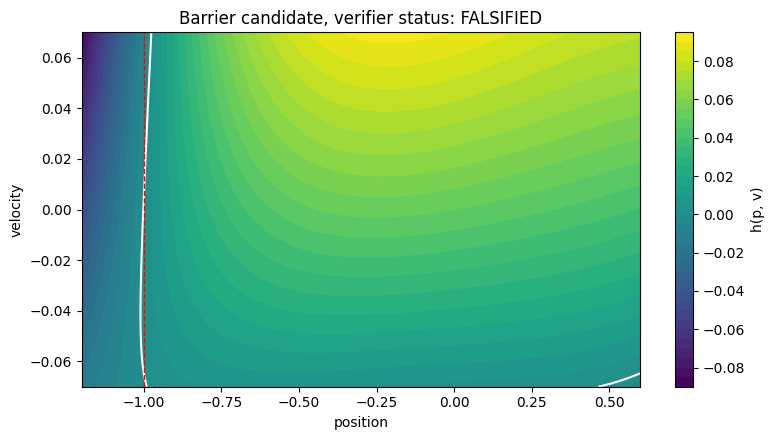

In [29]:
p = torch.linspace(-1.2, 0.6, 220)
v = torch.linspace(-0.07, 0.07, 140)
pp, vv = torch.meshgrid(p, v, indexing="ij")
states = torch.stack([pp.reshape(-1), vv.reshape(-1)], dim=-1)

with torch.no_grad():
    h = barrier.value(states).reshape(pp.shape).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
filled = ax.contourf(pp.numpy(), vv.numpy(), h, levels=40)
ax.contour(pp.numpy(), vv.numpy(), h, levels=[0.0], colors="white", linewidths=1.5)
ax.axvline(p_safe, color="red", linestyle="--", linewidth=1.0)
ax.set_xlabel("position")
ax.set_ylabel("velocity")
ax.set_title(f"Barrier candidate, verifier status: {report.status.value}")
fig.colorbar(filled, ax=ax, label="h(p, v)")
fig.tight_layout()
plot_path = ARTIFACT_DIR / "notebook_barrier_level_set.png"
fig.savefig(plot_path, dpi=160)
plot_path

## 7. Optional sanity check: deliberately unsafe policy

A policy that always accelerates left should not be certified safe. The verifier should return `FALSIFIED` or, with a very small budget, `UNKNOWN`; it must not return `VERIFIED` unless the barrier obligations are actually proved.

In [68]:
unsafe_policy = ConstantPolicy(-1.0)
unsafe_verifier = BranchAndBoundVerifier(
    dynamics,
    config=VerifierConfig(max_depth=10, max_boxes=5_000, min_width=5e-4),
)
unsafe_report = unsafe_verifier.verify(barrier, unsafe_policy, spec)
unsafe_report.to_dict()

{'status': 'FALSIFIED',
 'environment': 'MountainCarContinuous-v0',
 'policy_hash': 'f006c4915bce75dd9588871a11328f1acac2cba2af8b786e66f70b6301469193',
 'barrier_hash': 'ec6076790a7654e0ad5bf186823b7b430af8783c96a9c68fbd45b1a39eecf67c',
 'safety_threshold': -1.0,
 'initial_set': [[-0.6000000238418579, -0.4000000059604645], [0.0, 0.0]],
 'alpha': 1.0,
 'margins': {'initial': inf, 'unsafe': inf, 'invariance': inf},
 'boxes_processed': 1,
 'maximum_depth': 0,
 'counterexample': {'category': 'invariance',
  'state': [-1.0, -0.07000000029802322],
  'h': 0.0034224209375679493,
  'action': [-1.0],
  'next_state': [-1.0690250396728516, -0.06902502477169037],
  'h_next': -0.01915489137172699},
 'unresolved_boxes': None,
 'reason': 'invariance violation'}

## 8. Increasing the proof budget

If the neural-policy result is `UNKNOWN`, rerun synthesis/verification with larger settings, for example:

```python
LearnerConfig(epochs=2000, samples_domain=8192, ...)
VerifierConfig(max_depth=20, max_boxes=100_000, min_width=5e-5, ...)
```

Only a `VERIFIED` report with strictly positive margins should be treated as a barrier certificate.

## 9. Using a barrier to specify or learn a safe policy

A barrier can be used in two related ways:

1. **Manual safety filter:** start with a nominal policy and override its action only when the barrier condition would be violated.
2. **Barrier-guided learning:** train a neural policy with a differentiable penalty for one-step barrier decrease violations.

Both approaches still need formal verification before claiming safety. The barrier-filtered/manual policy below is useful for design and debugging; the learned neural policy can be passed back into the branch-and-bound verifier because it has interval bounds.

### 9.1 Manual policy from a barrier safety filter

The filter below evaluates a small set of candidate actions and selects the first action that satisfies the one-step barrier condition at the current point. If no action satisfies it, it chooses the action with the largest next-state barrier value.

This is a **pointwise controller**. To formally verify a filtered policy directly, the verifier would also need a sound interval abstraction for the filter's `argmax`/selection logic. Here we use it to show how a barrier can define a policy, then use sampled rollout diagnostics.

In [31]:
class BarrierFilteredPolicy:
    def __init__(self, nominal_policy, barrier, dynamics, *, alpha=0.1, eps_inv=1e-6):
        self.nominal_policy = nominal_policy
        self.barrier = barrier
        self.dynamics = dynamics
        self.alpha = float(alpha)
        self.eps_inv = float(eps_inv)
        self.candidate_actions = torch.tensor([-1.0, -0.5, 0.0, 0.5, 1.0]).reshape(-1, 1)

    def forward(self, state):
        single = state.ndim == 1
        states = state.unsqueeze(0) if single else state
        selected = []
        for row in states:
            row_batch = row.unsqueeze(0)
            h_now = self.barrier.value(row_batch)[0]
            beta_h = (1.0 - self.alpha) * h_now + self.eps_inv

            candidates = self.candidate_actions.to(dtype=row.dtype, device=row.device)
            repeated_states = row_batch.expand(candidates.shape[0], -1)
            next_states = self.dynamics.step(repeated_states, candidates)
            h_next = self.barrier.value(next_states)

            feasible = h_next >= beta_h
            if bool(feasible.any().item()):
                nominal = self.nominal_policy.forward(row_batch)[0, 0]
                feasible_actions = candidates[feasible]
                idx = torch.argmin((feasible_actions[:, 0] - nominal).abs())
                selected.append(feasible_actions[idx])
            else:
                selected.append(candidates[torch.argmax(h_next)])
        actions = torch.stack(selected, dim=0)
        return actions[0] if single else actions


filtered_policy = BarrierFilteredPolicy(policy, barrier, dynamics, alpha=spec.alpha, eps_inv=spec.eps_inv)

test_states = torch.tensor([
    [-0.99, -0.06],
    [-0.6, 0.0],
    [-0.2, 0.03],
])
with torch.no_grad():
    print("nominal actions :", policy.forward(test_states).squeeze(-1))
    print("filtered actions:", filtered_policy.forward(test_states).squeeze(-1))
    print("h now           :", barrier.value(test_states))
    print("h next filtered :", barrier.value(dynamics.step(test_states, filtered_policy.forward(test_states))))

nominal actions : tensor([0.017741, 0.017705, 0.017666])
filtered actions: tensor([1., 0., 0.])
h now           : tensor([0.000927, 0.044242, 0.069894])
h next filtered : tensor([-0.003029,  0.044545,  0.068576])


In [32]:
filtered_rollouts = empirical_rollouts(filtered_policy, episodes=5, seed=123, p_safe=p_safe)
filtered_rollouts

{'kind': 'empirical_rollout_not_proof',
 'episodes': 5,
 'unsafe_state_visits': 0,
 'mean_length': 999.0,
 'mean_return': 0.0}

### 9.2 Learn a neural policy with a barrier penalty

The next cell trains a fresh small neural policy against a simple objective:

- prefer positive/rightward actions, which are useful near the left safety threshold;
- penalize violations of the one-step barrier condition on sampled states.

This is not reinforcement learning; it is a compact supervised/constraint-style example showing how the barrier can shape a policy. After training, the policy is passed to the verifier exactly like any other fixed neural policy.

In [36]:
from barrier_tools.policies.pytorch_policy import FeedForwardPolicy, build_mlp

torch.manual_seed(7)
learned_policy = FeedForwardPolicy(build_mlp([2, 16, 16, 1], activation="tanh", final_tanh=True))
optimizer = torch.optim.Adam(learned_policy.parameters(), lr=3e-3)

train_box = invariant_domain
generator = torch.Generator().manual_seed(7)

for step in range(10_000):
    states = train_box.sample(1024, generator=generator)
    actions = learned_policy.forward(states)
    next_states = dynamics.step(states, actions)
    h_now = barrier.value(states)
    h_next = barrier.value(next_states)

    active = (h_now >= 0.0).float()
    barrier_violation = torch.relu((1.0 - spec.alpha) * h_now - h_next + spec.eps_inv)
    barrier_loss = (active * barrier_violation).sum() / active.sum().clamp_min(1.0)

    # Mild nominal term: push right, but let the barrier term dominate near unsafe motion.
    nominal_loss = ((actions - 0.6) ** 2).mean()
    loss = nominal_loss + 100.0 * barrier_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 150 == 0 or step == 599:
        print(
            f"step={step:03d}",
            f"loss={loss.item():.6f}",
            f"barrier_loss={barrier_loss.item():.6f}",
            f"mean_action={actions.mean().item():.3f}",
        )

step=000 loss=0.280701 barrier_loss=0.000086 mean_action=0.081


step=150 loss=0.006183 barrier_loss=0.000061 mean_action=0.602
step=300 loss=0.006099 barrier_loss=0.000061 mean_action=0.601
step=450 loss=0.009397 barrier_loss=0.000094 mean_action=0.601
step=599 loss=0.007451 barrier_loss=0.000074 mean_action=0.601
step=600 loss=0.007883 barrier_loss=0.000079 mean_action=0.601
step=750 loss=0.005986 barrier_loss=0.000060 mean_action=0.601
step=900 loss=0.006447 barrier_loss=0.000064 mean_action=0.601
step=1050 loss=0.008003 barrier_loss=0.000080 mean_action=0.601
step=1200 loss=0.008818 barrier_loss=0.000088 mean_action=0.601
step=1350 loss=0.008617 barrier_loss=0.000086 mean_action=0.601
step=1500 loss=0.005451 barrier_loss=0.000054 mean_action=0.601
step=1650 loss=0.006496 barrier_loss=0.000065 mean_action=0.601
step=1800 loss=0.006478 barrier_loss=0.000065 mean_action=0.601
step=1950 loss=0.006448 barrier_loss=0.000064 mean_action=0.601
step=2100 loss=0.005923 barrier_loss=0.000059 mean_action=0.601
step=2250 loss=0.006618 barrier_loss=0.000066 m

In [37]:
learned_rollouts = empirical_rollouts(learned_policy, episodes=5, seed=321, p_safe=p_safe)
learned_rollouts

{'kind': 'empirical_rollout_not_proof',
 'episodes': 5,
 'unsafe_state_visits': 0,
 'mean_length': 999.0,
 'mean_return': -36.08202163364915}

Now verify the learned policy. The learned policy is a standard feed-forward network with interval bounds, so it is compatible with the branch-and-bound verifier.

A result of `UNKNOWN` means the current barrier/policy/budget combination was not resolved. It does not mean the policy is safe.

In [38]:
learned_policy_report = verifier.verify(barrier, learned_policy, spec)
learned_policy_report.to_dict()

{'status': 'FALSIFIED',
 'environment': 'MountainCarContinuous-v0',
 'policy_hash': '462faf5108d40ebdc5f257e592a62c32085ec2f98a0ece8752c29a8ff79bd578',
 'barrier_hash': '965f2b88fa5f8780aaa42bbe2e10a59062ea9fd6d0a7927baa737827526f5faf',
 'safety_threshold': -1.0,
 'initial_set': [[-0.6000000238418579, -0.4000000059604645], [0.0, 0.0]],
 'alpha': 0.1,
 'margins': {'initial': inf, 'unsafe': inf, 'invariance': inf},
 'boxes_processed': 1,
 'maximum_depth': 0,
 'counterexample': {'category': 'invariance',
  'state': [-0.858436107635498, -0.05151573196053505],
  'h': 0.009778478182852268,
  'action': [0.6075910925865173],
  'next_state': [-0.906930685043335, -0.048494596034288406],
  'h_next': 0.007814631797373295},
 'unresolved_boxes': None,
 'reason': 'invariance violation'}

In [ ]:
# Intentionally left blank for ad-hoc experiments.

## 10. CEGIS-style barrier-safe policy training

The previous learned policy used a barrier loss, but it did not use verifier feedback. This section implements the three practical fixes:

1. **CEGIS:** verify the current policy, add counterexamples or unresolved box centers to the next training round, and retrain.
2. **Stronger batches:** oversample the barrier boundary, the safety threshold, the initial set, and verifier feedback states.
3. **Verifiable policy class:** keep the policy as a small `FeedForwardPolicy` made only from `Linear` and `Tanh`, so interval bounds are available.

This still does not guarantee that training will find a safe policy. It gives the verifier a better candidate to prove or refute.

In [ ]:
from torch import nn


SUPPORTED_POLICY_LAYERS = (nn.Linear, nn.Tanh, nn.ReLU, nn.Identity)


def assert_interval_verifiable_policy(candidate_policy, *, samples=512):
    """Fail early if the policy has layers unsupported by interval propagation."""
    if not isinstance(candidate_policy, FeedForwardPolicy):
        raise TypeError("Use FeedForwardPolicy so policy.interval(lower, upper) is available.")

    unsupported = [
        type(layer).__name__
        for layer in candidate_policy.model
        if not isinstance(layer, SUPPORTED_POLICY_LAYERS)
    ]
    if unsupported:
        raise TypeError(f"Unsupported interval-verification layers: {unsupported}")

    lower, upper = invariant_domain.as_batch()
    action_l, action_u = candidate_policy.interval(lower, upper)
    probe = invariant_domain.sample(samples, generator=torch.Generator().manual_seed(99))
    with torch.no_grad():
        actions = candidate_policy.forward(probe)
    if not bool((actions >= action_l - 1e-6).all().item()):
        raise AssertionError("Policy interval lower bound does not contain sampled actions.")
    if not bool((actions <= action_u + 1e-6).all().item()):
        raise AssertionError("Policy interval upper bound does not contain sampled actions.")
    return {"action_lower": action_l.detach(), "action_upper": action_u.detach()}


assert_interval_verifiable_policy(learned_policy)

### 10.1 Stronger barrier-focused batches

Uniform samples are weak. The sampler below mixes:

- uniform samples from the invariant domain;
- samples near the current barrier boundary `h(s) = 0`;
- samples near the safety threshold `p = p_safe`;
- samples from the initial set;
- verifier counterexamples and small neighborhoods around them.

In [ ]:
def clamp_to_box(states, box):
    return torch.minimum(torch.maximum(states, box.lower), box.upper)


def stronger_barrier_batch(
    barrier,
    *,
    counterexamples=None,
    n_domain=1024,
    n_boundary=512,
    n_threshold=512,
    n_initial=256,
    cex_radius=0.015,
    seed=0,
):
    generator = torch.Generator().manual_seed(int(seed))

    domain = invariant_domain.sample(n_domain, generator=generator)
    with torch.no_grad():
        scores = barrier.value(domain).abs()
    boundary_count = min(n_boundary, domain.shape[0])
    boundary = domain[torch.topk(scores, k=boundary_count, largest=False).indices]

    threshold_p = p_safe + 0.12 * torch.rand((n_threshold,), generator=generator)
    threshold_v = -0.07 + 0.14 * torch.rand((n_threshold,), generator=generator)
    threshold = torch.stack([threshold_p, threshold_v], dim=-1)

    initial = initial_set.sample(n_initial, generator=generator)
    batches = [domain, boundary, threshold, initial]

    if counterexamples:
        cex = torch.stack([item.float() for item in counterexamples], dim=0)
        noise = cex_radius * torch.randn(cex.shape[0] * 32, 2, generator=generator)
        repeated = cex.repeat_interleave(32, dim=0)
        batches.append(clamp_to_box(repeated + noise, invariant_domain))
        batches.append(clamp_to_box(cex, invariant_domain))

    return torch.cat(batches, dim=0)


demo_batch = stronger_barrier_batch(barrier, seed=0)
demo_batch.shape, barrier.value(demo_batch).min().item(), barrier.value(demo_batch).max().item()

### 10.2 Train one CEGIS round

The training loss is still sampled, but its sample distribution is now intentionally adversarial around the places where the proof can fail.

In [ ]:
def make_verifiable_policy(seed):
    torch.manual_seed(int(seed))
    return FeedForwardPolicy(build_mlp([2, 16, 16, 1], activation="tanh", final_tanh=True))


def train_barrier_guided_policy_round(
    candidate_policy,
    *,
    counterexamples=None,
    epochs=500,
    lr=3e-3,
    seed=0,
):
    assert_interval_verifiable_policy(candidate_policy, samples=128)
    optimizer = torch.optim.Adam(candidate_policy.parameters(), lr=lr)

    for epoch in range(int(epochs)):
        states = stronger_barrier_batch(
            barrier,
            counterexamples=counterexamples,
            n_domain=1024,
            n_boundary=768,
            n_threshold=768,
            n_initial=256,
            seed=seed + epoch,
        )
        actions = candidate_policy.forward(states)
        next_states = dynamics.step(states, actions)
        h_now = barrier.value(states)
        h_next = barrier.value(next_states)

        active = (h_now >= 0.0).float()
        barrier_violation = torch.relu((1.0 - spec.alpha) * h_now - h_next + spec.eps_inv)
        barrier_loss = (active * barrier_violation).sum() / active.sum().clamp_min(1.0)

        near_left = torch.sigmoid(80.0 * (p_safe + 0.10 - states[:, 0])).unsqueeze(-1)
        target_action = 0.25 + 0.75 * near_left
        nominal_loss = ((actions - target_action) ** 2).mean()
        action_regularizer = 1e-3 * (actions ** 2).mean()
        loss = nominal_loss + 250.0 * barrier_loss + action_regularizer

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return candidate_policy


round_policy = make_verifiable_policy(seed=11)
round_policy = train_barrier_guided_policy_round(round_policy, epochs=200, seed=11)
assert_interval_verifiable_policy(round_policy)

### 10.3 Full policy CEGIS loop

After every training round, the verifier is called. If it returns a concrete counterexample, the next training round samples that state and a small neighborhood around it. If it returns unresolved boxes, the next round samples the centers of a few unresolved boxes.

The loop stops early only on `VERIFIED`. Otherwise, inspect the final report and decide whether to increase the proof budget, change the policy architecture, or improve the barrier.

In [ ]:
def unresolved_box_centers(report, limit=16):
    centers = []
    for item in (report.unresolved_boxes or [])[:limit]:
        lower = torch.tensor(item["lower"], dtype=torch.float32)
        upper = torch.tensor(item["upper"], dtype=torch.float32)
        centers.append((lower + upper) / 2.0)
    return centers


def train_policy_with_cegis(
    *,
    rounds=4,
    train_epochs=350,
    seed=21,
    verifier_config=None,
):
    candidate_policy = make_verifiable_policy(seed)
    feedback_states = []
    reports = []
    cegis_verifier = BranchAndBoundVerifier(
        dynamics,
        config=verifier_config or VerifierConfig(max_depth=15, max_boxes=30_000, min_width=1e-4),
    )

    for round_idx in range(int(rounds)):
        candidate_policy = train_barrier_guided_policy_round(
            candidate_policy,
            counterexamples=feedback_states,
            epochs=train_epochs,
            seed=seed + 10_000 * round_idx,
        )
        assert_interval_verifiable_policy(candidate_policy, samples=256)
        report_i = cegis_verifier.verify(barrier, candidate_policy, spec)
        reports.append(report_i)
        print(
            f"round={round_idx}",
            f"status={report_i.status.value}",
            f"boxes={report_i.boxes_processed}",
            f"reason={report_i.reason}",
        )

        if report_i.status == VerificationStatus.VERIFIED:
            break
        if report_i.counterexample is not None:
            feedback_states.append(torch.tensor(report_i.counterexample["state"], dtype=torch.float32))
        feedback_states.extend(unresolved_box_centers(report_i, limit=8))

    return candidate_policy, reports, feedback_states


cegis_policy, cegis_reports, cegis_feedback_states = train_policy_with_cegis(
    rounds=3,
    train_epochs=250,
    seed=21,
)

[report.to_dict()["status"] for report in cegis_reports]

Finally, save the CEGIS-trained policy and its latest verification report. Treat it as provably safe only if the latest status is `VERIFIED` with positive margins.

In [ ]:
cegis_policy_path = ARTIFACT_DIR / "cegis_barrier_guided_policy.pt"
cegis_report_path = ARTIFACT_DIR / "cegis_barrier_guided_policy_report.json"

torch.save(cegis_policy.checkpoint_payload([2, 16, 16, 1]), cegis_policy_path)
latest_cegis_report = cegis_reports[-1]
latest_cegis_report.save(cegis_report_path)

print("latest status:", latest_cegis_report.status.value)
print("latest margins:", latest_cegis_report.margins)
print("feedback states used:", len(cegis_feedback_states))
cegis_policy_path, cegis_report_path

## 11. Diagnosing why CEGIS did not make the policy safe

If CEGIS repeatedly returns the same invariance counterexample, check whether the fixed barrier condition is feasible at that state. The policy can only choose actions in `[-1, 1]`; if no action satisfies

$$h(F(s, u)) \ge (1 - \alpha)h(s) + \epsilon_{inv},$$

then policy retraining alone cannot solve the problem. The barrier must be changed, the contract must be relaxed, or the certified domain must be refined.

In [ ]:
def diagnose_action_feasibility_at_counterexample(report, *, n_actions=401):
    if report.counterexample is None:
        print("No counterexample in this report.")
        return None

    state = torch.tensor(report.counterexample["state"], dtype=torch.float32).unsqueeze(0)
    h_now = barrier.value(state)[0].detach()
    required = (1.0 - spec.alpha) * h_now + spec.eps_inv

    actions = torch.linspace(-1.0, 1.0, n_actions).reshape(-1, 1)
    repeated_states = state.expand(actions.shape[0], -1)
    next_states = dynamics.step(repeated_states, actions)
    with torch.no_grad():
        h_next = barrier.value(next_states)

    best_idx = int(torch.argmax(h_next).item())
    best_action = actions[best_idx]
    best_h_next = h_next[best_idx]
    feasible = h_next >= required
    alpha_needed = max(0.0, 1.0 - float(best_h_next / h_now))

    return {
        "state": state.squeeze(0).tolist(),
        "h_now": float(h_now),
        "required_h_next_with_current_alpha": float(required),
        "best_action_in_grid": float(best_action.item()),
        "best_h_next": float(best_h_next),
        "best_gap": float(best_h_next - required),
        "any_grid_action_feasible": bool(feasible.any().item()),
        "minimum_alpha_needed_at_this_state": alpha_needed,
    }


diagnose_action_feasibility_at_counterexample(latest_cegis_report)

For the saved run, the best action is expected to be near `u = 1`, but the best achievable `h_next` is still below the required value for `alpha = 0.1`. This means the CEGIS policy learner is being asked to satisfy an impossible one-step contract for the current fixed barrier at that state.

Practical fixes:

- co-synthesize the barrier and the policy instead of freezing the barrier;
- use a less aggressive decrease condition, for example larger `alpha`, if the safety argument permits it;
- train the barrier with this exact policy CEGIS loop, not only train the policy;
- restrict the invariant domain to a verified reachable over-approximation rather than the whole configured safe side;
- use a stronger action filter/controller class whose own selection logic can be verified.